In [1]:
import json 
import matplotlib.pyplot as plt
import os
from aeon.visualisation import plot_critical_difference
import pandas as pd

In [2]:
dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#000000",  # intense blue
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "WU RevIN":              "#FF3300",  # bright red-orange
    "WU RevIN + asinh":      "#CC0099",  # strong magenta
}

dic_model_symbols = {
    "Causal RevIN":          "o",   # circle
    "Causal RevIN + asinh":  "x",   # cross
    "RevIN":                 "s",   # square
    "RevIN + asinh":         "d",   # diamond
    "WU RevIN":              "^",   # triangle up
    "WU RevIN + asinh":      "v",   # triangle down
}

In [3]:
HORIZON = 64

# overall with all context lengths
CTX_LENS = [128, 256, 512]
full_df = {}
for CTX_LEN in CTX_LENS:

    with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_causal_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_causal_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_causal_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_causal_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_causal_asinh_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_causal_asinh_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_asinh_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_asinh_artificial = json.load(f)
        

    with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_WURevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_wu_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_WURevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_wu_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_WURevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_wu_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_WURevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_wu_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_WURevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_wu_asinh_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_WURevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_wu_asinh_artificial = json.load(f)
    
    full_df[CTX_LEN] = {}
    full_df[CTX_LEN]['Causal RevIN'] = {
        'GIFT-Eval': metrics_causal_gift_eval,
        'UTSD': metrics_causal_utsd,
        'Artificial': metrics_causal_artificial
    }
    full_df[CTX_LEN]['Causal RevIN + asinh'] = {
        'GIFT-Eval': metrics_causal_asinh_gift_eval,
        'UTSD': metrics_causal_asinh_utsd,
        'Artificial': metrics_causal_asinh_artificial
    }
    full_df[CTX_LEN]['RevIN + asinh'] = {
        'GIFT-Eval': metrics_asinh_gift_eval,
        'UTSD': metrics_asinh_utsd,
        'Artificial': metrics_asinh_artificial
    }
    full_df[CTX_LEN]['RevIN'] = {
        'GIFT-Eval': metrics_gift_eval,
        'UTSD': metrics_utsd,
        'Artificial': metrics_artificial
    }
    full_df[CTX_LEN]['WU RevIN'] = {
        'GIFT-Eval': metrics_wu_gift_eval,
        'UTSD': metrics_wu_utsd,
        'Artificial': metrics_wu_artificial
    }
    full_df[CTX_LEN]['WU RevIN + asinh'] = {
        'GIFT-Eval': metrics_wu_asinh_gift_eval,
        'UTSD': metrics_wu_asinh_utsd,
        'Artificial': metrics_wu_asinh_artificial
    }

models_results_mae = {}
models_results_mse = {}

for context, models_results in full_df.items():
    for model_name, datasets_results in models_results.items():
        for dataset_name, metrics in datasets_results.items():
            for metric_horizon, value in metrics.items():
                metric, horizon = metric_horizon.split("_")
                if horizon != str(HORIZON):
                    continue
                
                if metric.lower() == "mae":
                    if dataset_name not in models_results_mae:
                        models_results_mae[dataset_name] = {}
                    if model_name not in models_results_mae[dataset_name]:
                        models_results_mae[dataset_name][model_name] = {}
                    models_results_mae[dataset_name][model_name][context] = value

                elif metric.lower() == "rmse":
                    if dataset_name not in models_results_mse:
                        models_results_mse[dataset_name] = {}
                    if model_name not in models_results_mse[dataset_name]:
                        models_results_mse[dataset_name][model_name] = {}
                    models_results_mse[dataset_name][model_name][context] = value

# UTSD

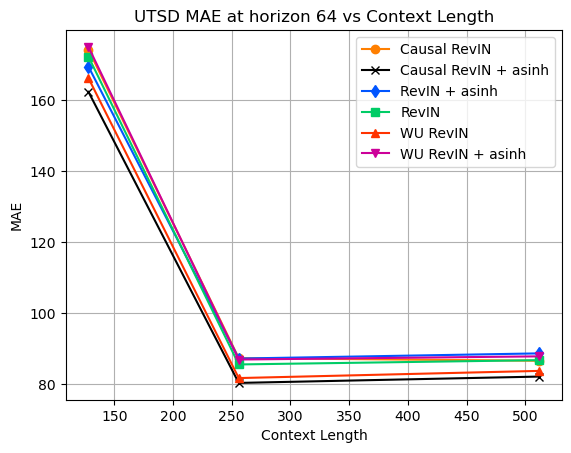

In [4]:
utsd_results_mae = pd.DataFrame(models_results_mae['UTSD'])

for model, results in utsd_results_mae.items():
    plt.plot(results.index, results.values, marker=dic_model_symbols[model], color=dic_model_colors[model], label=model)
plt.legend()
plt.title(f"UTSD MAE at horizon {HORIZON} vs Context Length")
plt.xlabel("Context Length")
plt.ylabel("MAE")
plt.grid()
plt.show()

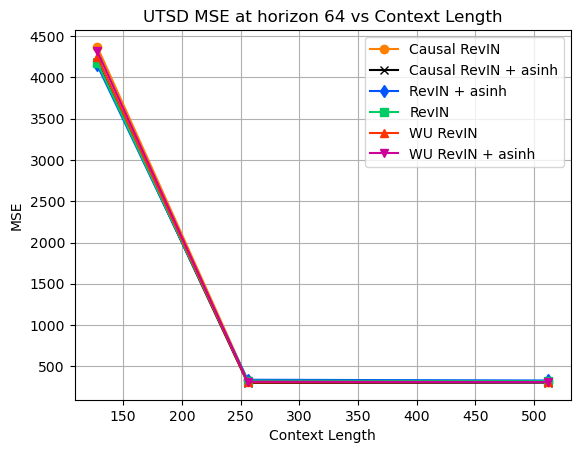

In [5]:
utsd_results_mse = pd.DataFrame(models_results_mse['UTSD'])

for model, results in utsd_results_mse.items():
    plt.plot(results.index, results.values, marker=dic_model_symbols[model], color=dic_model_colors[model], label=model)
plt.legend()
plt.title(f"UTSD MSE at horizon {HORIZON} vs Context Length")
plt.xlabel("Context Length")
plt.ylabel("MSE")
plt.grid()
plt.show()

# GIFT-Eval

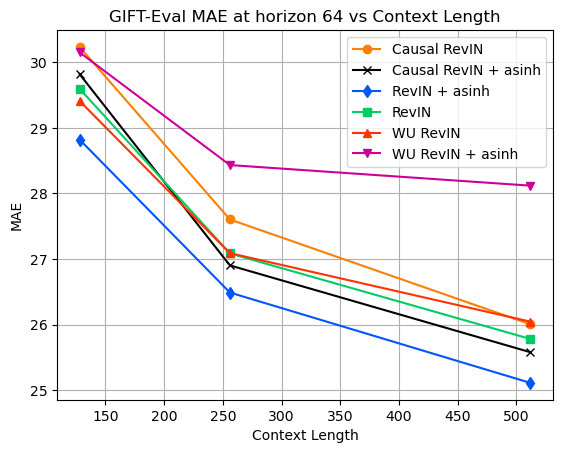

In [6]:
gifteval_results_mae = pd.DataFrame(models_results_mae['GIFT-Eval'])

for model, results in gifteval_results_mae.items():
    plt.plot(results.index, results.values, marker=dic_model_symbols[model], color=dic_model_colors[model], label=model)
plt.legend()
plt.title(f"GIFT-Eval MAE at horizon {HORIZON} vs Context Length")
plt.xlabel("Context Length")
plt.ylabel("MAE")
plt.grid()
plt.show()

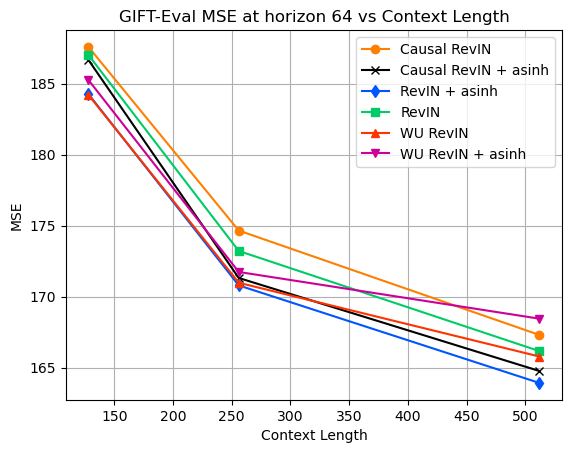

In [7]:
gifteval_results_mse = pd.DataFrame(models_results_mse['GIFT-Eval'])

for model, results in gifteval_results_mse.items():
    plt.plot(results.index, results.values, marker=dic_model_symbols[model], color=dic_model_colors[model], label=model)
plt.legend()
plt.title(f"GIFT-Eval MSE at horizon {HORIZON} vs Context Length")
plt.xlabel("Context Length")
plt.ylabel("MSE")
plt.grid()
plt.show()

# Artificial

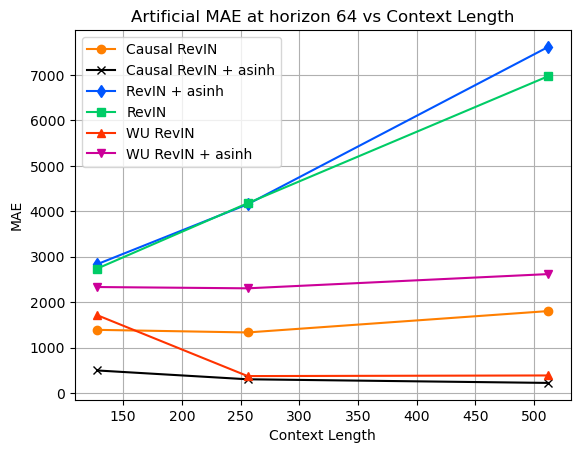

In [8]:
artificial_results_mae = pd.DataFrame(models_results_mae['Artificial'])

for model, results in artificial_results_mae.items():
    plt.plot(results.index, results.values, marker=dic_model_symbols[model], color=dic_model_colors[model], label=model)
plt.legend()
plt.title(f"Artificial MAE at horizon {HORIZON} vs Context Length")
plt.xlabel("Context Length")
plt.ylabel("MAE")
plt.grid()
plt.show()

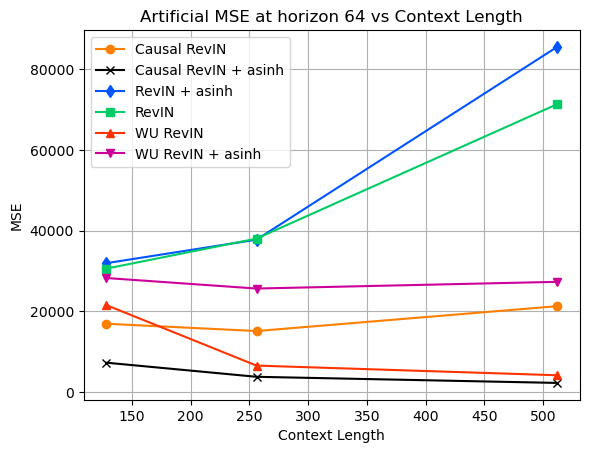

In [9]:
artificial_results_mse = pd.DataFrame(models_results_mse['Artificial'])

for model, results in artificial_results_mse.items():
    plt.plot(results.index, results.values, marker=dic_model_symbols[model], color=dic_model_colors[model], label=model)
plt.legend()
plt.title(f"Artificial MSE at horizon {HORIZON} vs Context Length")
plt.xlabel("Context Length")
plt.ylabel("MSE")
plt.grid()
plt.show()